In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [12]:

import re
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
DATASET_PATH = "/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
df = pd.read_csv(DATASET_PATH)
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["review"] = df["review"].apply(clean_text)
df["sentiment"] = df["sentiment"].map({"positive":1, "negative":0})


In [6]:
X = df["review"].values
y = df["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
NUM_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_p = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

X_test_p = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding="post", truncating="post"
)


In [8]:
def make_simple_rnn():
    model = Sequential([
        Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
        SimpleRNN(128),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model
    
def make_lstm():
    model = Sequential([
        Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
        LSTM(128),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

def make_gru():
    model = Sequential([
        Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
        GRU(128),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

def make_bilstm():
    model = Sequential([
        Embedding(NUM_WORDS, 128, input_length=MAX_LEN),
        Bidirectional(LSTM(128)),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


In [9]:
def train_plot(model_fn, label):
    print(f"--- {label} ---")

    model = model_fn()
    early = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_p,
        y_train,
        validation_split=0.2,
        epochs=7,
        batch_size=64,
        callbacks=[early],
        verbose=1
    )

    # Plot training curves
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"{label} Training Curves")

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train acc")
    plt.plot(history.history["val_accuracy"], label="val acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.show()

    # Evaluate on test set
    loss, acc = model.evaluate(X_test_p, y_test, verbose=0)
    preds = (model.predict(X_test_p, verbose=0) > 0.5).astype("int32")
    f1 = f1_score(y_test, preds)

    print(f"{label} Test Acc: {acc:.4f}, F1: {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{label} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print(classification_report(y_test, preds))

    return {
        "model": model,
        "accuracy": acc,
        "f1": f1,
        "history": history
    }


--- Simple RNN ---
Epoch 1/7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-12-27 09:10:15.855208: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - accuracy: 0.4961 - loss: 0.7279 - val_accuracy: 0.4992 - val_loss: 0.6936
Epoch 2/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.5044 - loss: 0.7075 - val_accuracy: 0.5066 - val_loss: 0.6937
Epoch 3/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - accuracy: 0.5029 - loss: 0.6969 - val_accuracy: 0.4949 - val_loss: 0.6936


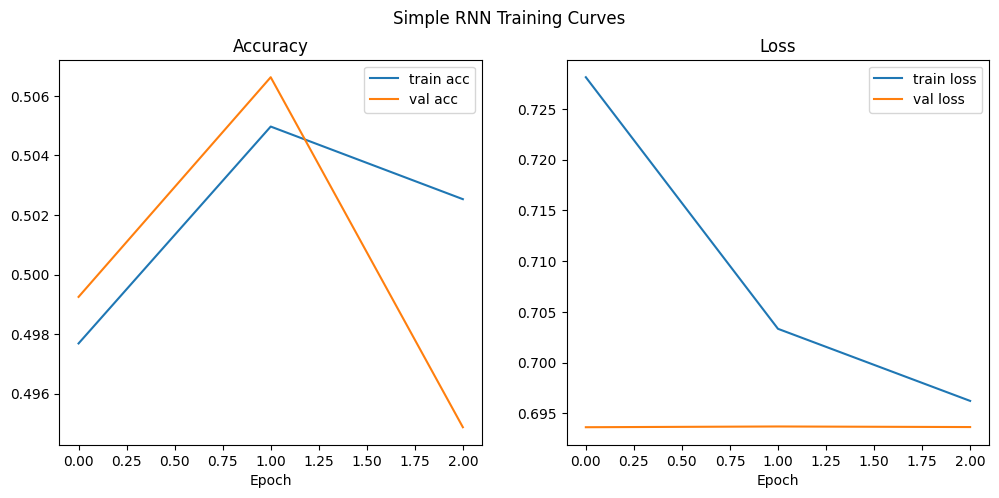

Simple RNN Test Acc: 0.4990, F1: 0.4001


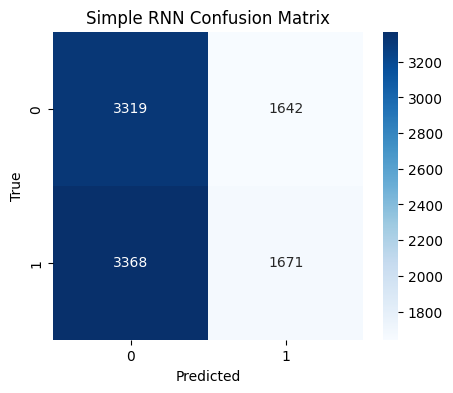

              precision    recall  f1-score   support

           0       0.50      0.67      0.57      4961
           1       0.50      0.33      0.40      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.48     10000



In [10]:
results = {}

results["Simple RNN"] = train_plot(make_simple_rnn, "Simple RNN")

--- LSTM ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 273ms/step - accuracy: 0.5189 - loss: 0.6945 - val_accuracy: 0.6858 - val_loss: 0.6629
Epoch 2/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 275ms/step - accuracy: 0.6028 - loss: 0.6537 - val_accuracy: 0.6948 - val_loss: 0.6121
Epoch 3/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 274ms/step - accuracy: 0.7143 - loss: 0.5756 - val_accuracy: 0.6240 - val_loss: 0.6496
Epoch 4/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 138s 275ms/step - accuracy: 0.6998 - loss: 0.5818 - val_accuracy: 0.8537 - val_loss: 0.3639
Epoch 5/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 271ms/step - accuracy: 0.8965 - loss: 0.2903 - val_accuracy: 0.8413 - val_loss: 0.3887
Epoch 6/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9263 - loss: 0.2278 - val_accuracy: 0.8705 - val_loss: 0.3476
Epoch 7/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 136s 272ms/step - accuracy: 0.9602 - loss: 0.1438 - val_accuracy: 0.8660 - val_loss: 0.3788


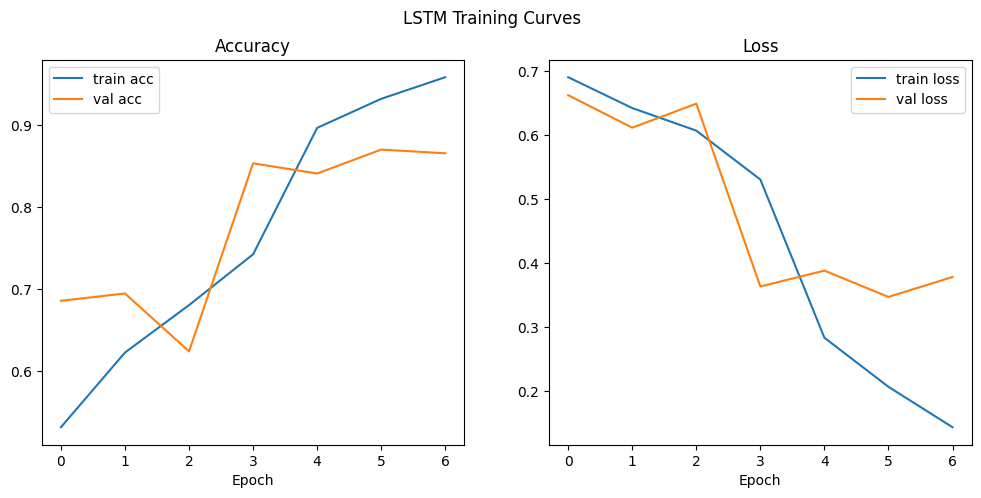

LSTM Test Acc: 0.8745, F1: 0.8761


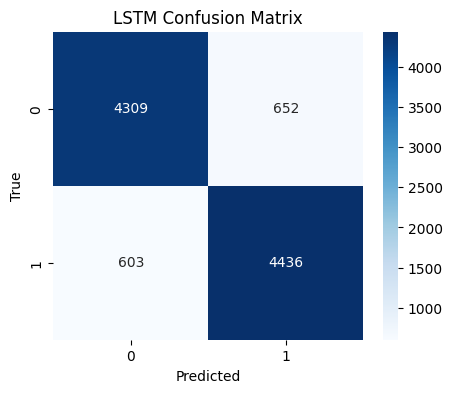

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4961
           1       0.87      0.88      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [11]:
results["LSTM"] = train_plot(make_lstm, "LSTM")

--- GRU ---
Epoch 1/7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 290ms/step - accuracy: 0.5077 - loss: 0.6940 - val_accuracy: 0.5449 - val_loss: 0.6831
Epoch 2/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 135s 269ms/step - accuracy: 0.5991 - loss: 0.6699 - val_accuracy: 0.7191 - val_loss: 0.5680
Epoch 3/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 290ms/step - accuracy: 0.7286 - loss: 0.5452 - val_accuracy: 0.8380 - val_loss: 0.3764
Epoch 4/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 268ms/step - accuracy: 0.8944 - loss: 0.2735 - val_accuracy: 0.8553 - val_loss: 0.3430
Epoch 5/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 267ms/step - accuracy: 0.9429 - loss: 0.1683 - val_accuracy: 0.8751 - val_loss: 0.3357
Epoch 6/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 266ms/step - accuracy: 0.9759 - loss: 0.0836 - val_accuracy: 0.8683 - val_loss: 0.4148
Epoch 7/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 265ms/step - accuracy: 0.9873 - loss: 0.0499 - val_accuracy: 0.8625 - val_loss: 0.4745


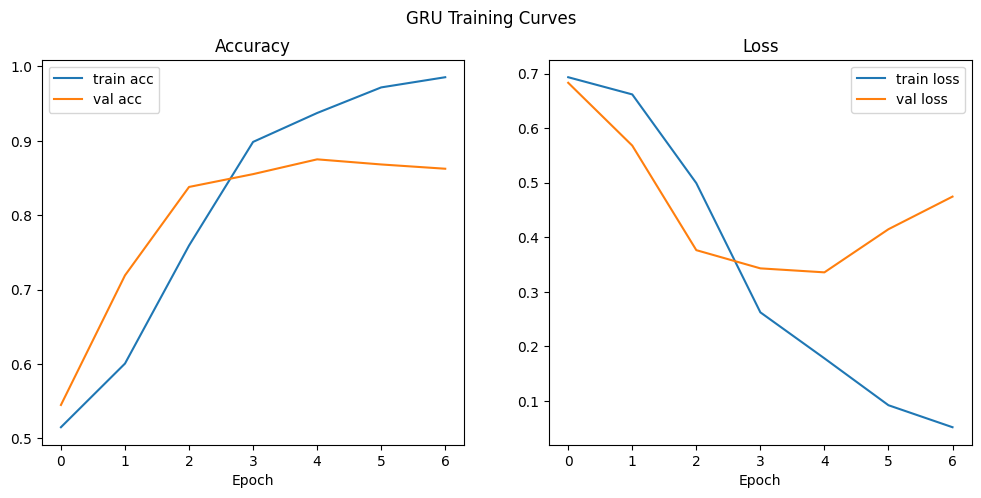

GRU Test Acc: 0.8766, F1: 0.8775


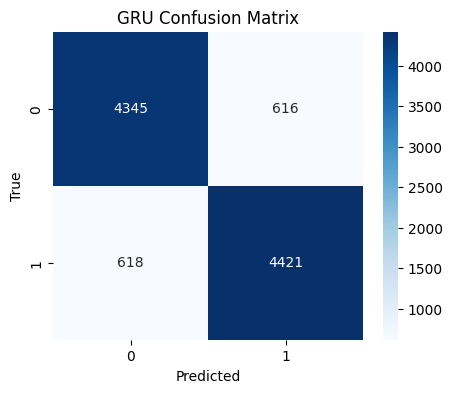

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4961
           1       0.88      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [12]:
results["GRU"] = train_plot(make_gru, "GRU")

--- Bidirectional LSTM ---
Epoch 1/7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 221s 437ms/step - accuracy: 0.6563 - loss: 0.5980 - val_accuracy: 0.8099 - val_loss: 0.4279
Epoch 2/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 217s 435ms/step - accuracy: 0.8683 - loss: 0.3280 - val_accuracy: 0.8719 - val_loss: 0.3445
Epoch 3/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 222s 444ms/step - accuracy: 0.9252 - loss: 0.2091 - val_accuracy: 0.8556 - val_loss: 0.3886
Epoch 4/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 224s 449ms/step - accuracy: 0.9453 - loss: 0.1548 - val_accuracy: 0.8522 - val_loss: 0.4233


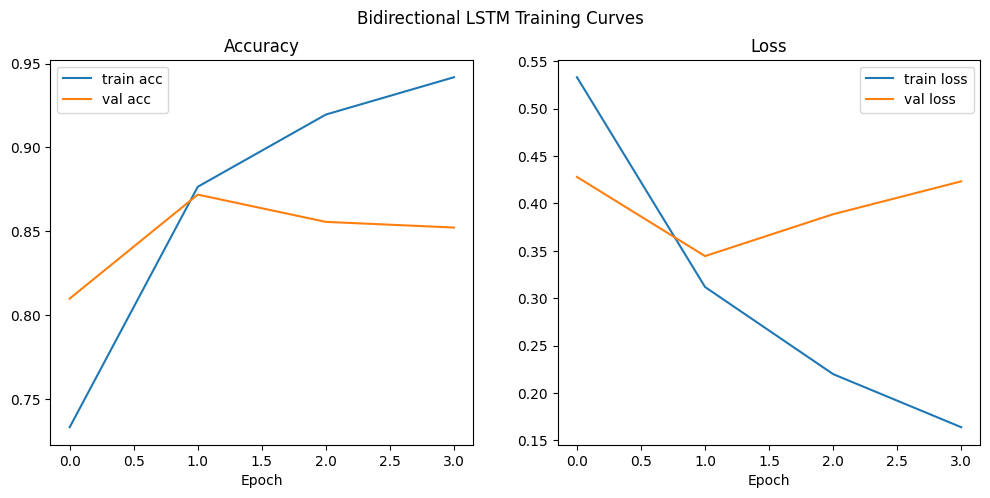

Bidirectional LSTM Test Acc: 0.8749, F1: 0.8755


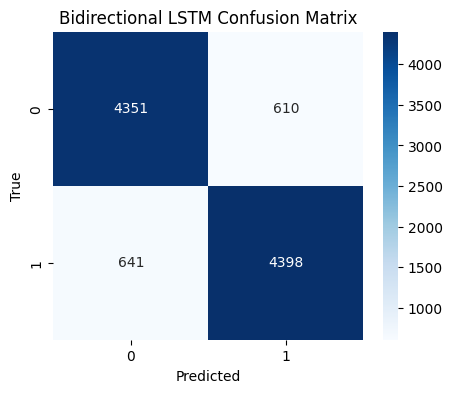

              precision    recall  f1-score   support

           0       0.87      0.88      0.87      4961
           1       0.88      0.87      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [13]:
results["BiLSTM"] = train_plot(make_bilstm, "Bidirectional LSTM")

In [15]:
test_samples = [
    "This movie was absolutely fantastic! Great acting, amazing plot, and wonderful cinematography.",
    "I absolutely loved this film. The characters were well-developed and the story was engaging.",
    "This movie was terrible. Poor acting, boring plot, and awful direction made it unwatchable.",
    "I hated this film. It was too long, confusing, and the characters were not interesting.",
    "The movie was okay, nothing special but not bad either. Average entertainment.",
    "Outstanding performance! This is definitely one of the best movies I've ever seen.",
    "Worst movie experience ever! Complete waste of time and money."
]


In [16]:
best_model_name = max(results, key=lambda x: results[x]["f1"])
best_model = results[best_model_name]["model"]

print("Best model selected:", best_model_name)


Best model selected: GRU


In [17]:
for i, sample in enumerate(test_samples, 1):
    print(f"\n{i}. Review:")
    print(sample)

    # 1. Curățare text (aceeași funcție ca la training)
    cleaned_sample = clean_text(sample)

    # 2. Tokenizare
    sequence = tokenizer.texts_to_sequences([cleaned_sample])

    # 3. Padding
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN)

    # 4. Predicție (probabilitate)
    prediction_prob = best_model.predict(padded_sequence)[0][0]

    # 5. Clasificare
    predicted_label = "Positive" if prediction_prob >= 0.5 else "Negative"
    confidence = prediction_prob if prediction_prob >= 0.5 else 1 - prediction_prob

    print(f"   Predicted sentiment: {predicted_label}")
    print(f"   Confidence: {confidence * 100:.2f}%")



1. Review:
This movie was absolutely fantastic! Great acting, amazing plot, and wonderful cinematography.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
   Predicted sentiment: Positive
   Confidence: 99.58%

2. Review:
I absolutely loved this film. The characters were well-developed and the story was engaging.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
   Predicted sentiment: Positive
   Confidence: 84.84%

3. Review:
This movie was terrible. Poor acting, boring plot, and awful direction made it unwatchable.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
   Predicted sentiment: Negative
   Confidence: 99.73%

4. Review:
I hated this film. It was too long, confusing, and the characters were not interesting.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
   Predicted sentiment: Negative
   Confidence: 94.63%

5. Review:
The movie was okay, nothing special but not bad either. Average entertainment.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
   Predicted sentiment: Negative
   Confidence: 94.37%

6. Review:
Outstanding p